<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFFF; max-width: 90%; overflow-x: auto; color: #000000;">

<h1 align="center">Workshop 2: Nonsense correlations from slow fluctuations</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain</h3>
<h4 align="center">Thursday, August 27th, 2026</h4>
<h4 align="center">Day 4</h4>

---

**Authors:** Nick Steinmetz, Carrie Stine

---

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">


## Introduction

Neurons fluctuate slowly. Even with no stimulus and no task event, firing rates drift up and down over tens of seconds. So do behavioral signals like pupil diameter and running speed. When two slow signals share the same recording session, they will appear correlated even if neither caused the other. This is the **nonsense correlation** problem, and it shows up in almost every large-scale recording dataset, including the Dynamic Routing data we saw earlier this week (refer to the [Databook](https://allenswdb.github.io/physiology/ephys/ephys-overview.html#dynamic-routing) for more details).

How well do standard safeguards (shuffling trials, k-fold cross-validation, etc.) perform when our data has a slowly-varying task variable and slow neural drift?

In this workshop we will build the problem from scratch **in simulation** (where we know the ground truth), identify which controls fail and why, and derive the ones that actually work. In the extended exercises, we will apply the same pipeline to a real Dynamic Routing session to see the artifact in real data and apply the appropriate controls.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Learning Objectives

By the end of this workshop you will be able to:

1. **Simulate** a null hypothesis data set to test the validity of different analysis workflows.
2. **Recognize** the slow-fluctuation pitfall.
3. **Identify** which standard controls fail or succeed.
4. **Apply** two controls that work for pupil-type correlations.
5. **Understand** the concept of *effective N* and how autocorrelation inflates false-positive rates.
6. **Apply** pseudosession and leave-one-block-out cross-validation for block-variable decoding.

In the extended exercises section at the end, you will learn how to apply all of these principles on real Dynamic Routing data.

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 0. Setup

Run this cell first. It imports every package used in this notebook. By now you should be familiar with <code style="background: #e0e0e0; color: #000000; padding: 1px 4px; border-radius: 3px; font-family: monospace;">numpy</code>, <code style="background: #e0e0e0; color: #000000; padding: 1px 4px; border-radius: 3px; font-family: monospace;">matplotlib</code>, and <code style="background: #e0e0e0; color: #000000; padding: 1px 4px; border-radius: 3px; font-family: monospace;">scipy</code>. Some new packages that you may not have used yet:
- <code style="background: #e0e0e0; color: #000000; padding: 1px 4px; border-radius: 3px; font-family: monospace;">sklearn</code>: abbreviated from scikit-learn, Python's standard machine learning library. Here we import two tools from <code style="background: #e0e0e0; color: #000000; padding: 1px 4px; border-radius: 3px; font-family: monospace;">sklearn</code>:
    - **LDA (Linear Discriminant Analysis)**: used for neural decoding
    - **KFold**: used to split data into training and test sets for cross-validation
- <code style="background: #e0e0e0; color: #000000; padding: 1px 4px; border-radius: 3px; font-family: monospace;">ipympl</code>: used to make matplotlib figures into an interactive widget inside Jupyter (does not get imported directly into the notebook, but needs to be in the environment)


</div>


In [1]:
# standard imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold




# Global figure settings
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


# Part 1 — Simulating Null Data


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 1. Simulate a Session

Imagine an experiment where we will record from a population of 100 slowly fluctuating neurons during a task that alternates between two conditions or **blocks**, which we will call +1 or -1. Each block consists of roughly 30-70 trials, each trial lasts for 1 second, and the full session lasts about 500 trials. Alongside the neural recording, we are also tracking the animal's **pupil diameter** as a measure of arousal.

**Two questions:**

*1. Are any of the neurons modulated by the animal's arousal state?* <br>
*2. Can we decode the block identity from the neural activity?*

---

We record from 100 neurons across a session, measure pupil diameter trial by trial, and create an analysis workflow that we believe will identify which neurons have firing rates that correlate with pupil size.

If we apply our analysis on real data and find an effect, is that a real result? Or is it an artifact of how we set up the analysis? 

This is where **simulated data** becomes invaluable. We can build a synthetic dataset that captures the key statistical features of a real session, but where we know that there is *no true effect*, to determine if our analysis workflow has an acceptable false positive rate. 

We will first build a **completely synthetic dataset** in which we know the ground truth:
the neurons have *no* relationship to either the pupil or the task block variable. 


Our simulated dataset contains 100 neurons whose firing rates fluctuate slowly (25 s timescale) around their own mean rate, with spike trains drawn as an inhomogeneous Poisson process. The pupil trace has a similar slow structure (20 s timescale). 

### Key parameters

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `N_NEURONS` | 100 | number of simulated neurons |
| `N_BLOCKS` | 10 | task blocks per session |
| `TRIAL_DUR` | 1.0 s | duration of one trial |
| `FLUCT_TAU` | 25 s | **timescale of each neuron's slow rate fluctuation** |
| `PUPIL_TAU` | 20 s | timescale of the pupil fluctuation |
| `RATE_BASE` | 2–9 spikes/s | each neuron's mean firing rate |
| `RATE_AMP` | 2.5 spikes/s | SD of the slow fluctuation |

<br>

</div>


In [2]:
# Simulation parameters
SEED        = 7            # master random seed — keep this fixed to reproduce figures

N_NEURONS   = 100
N_BLOCKS    = 10           # task blocks in the session
BLOCK_LEN   = (30, 70)     # trials per block, drawn uniformly (inclusive)
TRIAL_DUR   = 1.0          # s, duration of one trial
DT          = 0.005        # s, resolution at which spikes are generated (5 ms bins)

FLUCT_TAU   = 25.0         # s, timescale of each neuron's slow rate fluctuation
PUPIL_TAU   = 20.0         # s, timescale of the pupil fluctuation
RATE_BASE   = (2.0, 9.0)   # spikes/s, each neuron's mean rate (drawn uniformly)
RATE_AMP    = 2.5          # spikes/s, SD of the slow fluctuation around that mean
TP_NOISE_SD = 0.0          # extra independent noise (0 = Poisson noise only)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Helper functions

**Helper functions** are reusable pieces of code that handle a repeated task (formatting a plot, computing a metric, running an analysis step, etc). Rather than copying the same code into every notebook or cell that needs it, we can define it **once** and call it by name. 

To keep our notebook code tidy, we will organize our helper functions into a separate `utils` script called `workshop2_utils.py`. Feel free to open that script if you would like to see more details about how any of the helper functions operate.

--- 

**We will first import the following two helper functions:**

`slow_traces` generates smoothed random signals by low-pass filtering white noise
with a Gaussian kernel of width `tau_pts` samples, then z-scoring each row.
The `mode='wrap'` flag makes each trace **periodic**.

`make_blocks` produces a sequence of alternating +1/−1 blocks with random lengths,
mimicking how a task block variable might be structured in a real experiment.

</div>


In [3]:
# setup code for importing helper functions
import sys, importlib
sys.path.append('utils')
import workshop2_utils
importlib.reload(workshop2_utils) # automatically reloads helper functions if they are changed while kernel is running

# import the first two helper functions
from workshop2_utils import slow_traces, make_blocks

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Build the simulated data

We will now build the full simulated dataset in three steps.

1. **Task structure**: `make_blocks` generates the sequence of +1/−1 block labels for every trial. From this we also compute two useful numbers: `n_trials` (how many trials the session has) and `per_trial` (how many 5 ms time bins fit in one trial).

2. **Neural activity**: each neuron is assigned a random baseline firing rate drawn uniformly between 2 and 9 spikes/s, then a slow fluctuation is added on top. The fluctuation is a smooth random trace with a 25 second timescale. The rates are then interpolated onto the fine 5 ms time grid and spikes are drawn bin-by-bin from a Poisson distribution. The result is a **matrix of spike counts with shape (neurons × timepoints)**.

3. **Pupil diameter**: The pupil trace is generated the same way, but on a 20 second timescale. It is drawn after the neurons and *shares no information with them.* 

</div>


In [4]:
rng = np.random.default_rng(SEED)

# --- the task variable: alternating +/-1 blocks
block_values, block_ids = make_blocks(rng, n_blocks=N_BLOCKS, lo=BLOCK_LEN[0], hi=BLOCK_LEN[1], n_trials=None)

n_trials  = len(block_values)                   # number of trials generated
per_trial = int(round(TRIAL_DUR / DT))          # timepoints in one trial
n_pts     = n_trials * per_trial                # timepoints in the session

# --- each neuron's firing rate: mean rate + slow fluctuation
# Nothing here depends on block_values or on the pupil.
rate_trial = (rng.uniform(*RATE_BASE, size=N_NEURONS)[:, None]
              + RATE_AMP * slow_traces(rng, N_NEURONS, n_trials, FLUCT_TAU / TRIAL_DUR))
rate_trial = rate_trial + rng.normal(0, TP_NOISE_SD, rate_trial.shape) # noise is 0 by default
rate_trial = np.clip(rate_trial, 0, None)     # firing rate cannot be negative

# --- interpolate to the fine time grid and draw Poisson spikes: independently in each
# 5 ms bin, the number of spikes is Poisson with mean rate * DT. 
t_trial = (np.arange(n_trials) + 0.5) * TRIAL_DUR   # trial centres (s)
t_pts   = np.arange(n_pts) * DT                     # fine time grid (s)
rate    = np.array([np.interp(t_pts, t_trial, r) for r in rate_trial])   # spikes/s
spikes  = rng.poisson(rate * DT)              # shape: (neurons, timepoints)

# --- pupil diameter: same kind of slow trace, independent of everything
pupil = 0.5 + 0.15 * slow_traces(rng, 1, n_trials, PUPIL_TAU / TRIAL_DUR)[0]

print(f'{N_NEURONS} neurons, {n_trials} trials ({n_trials*TRIAL_DUR/60:.1f} min), {N_BLOCKS} blocks')
print(f'Firing rates: {rate.min():.1f} - {rate.max():.1f} spikes/s (mean {rate.mean():.1f})')
print(f'{spikes.sum():,} spikes total')


100 neurons, 511 trials (8.5 min), 10 blocks
Firing rates: 0.0 - 17.3 spikes/s (mean 5.3)
272,746 spikes total


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 2. Visualize the spike raster plot

A **raster plot** shows every spike as a tick mark, with neurons on the y-axis
and time on the x-axis. Here we show the first 60 s (60 trials) for 12 neurons.

</div>


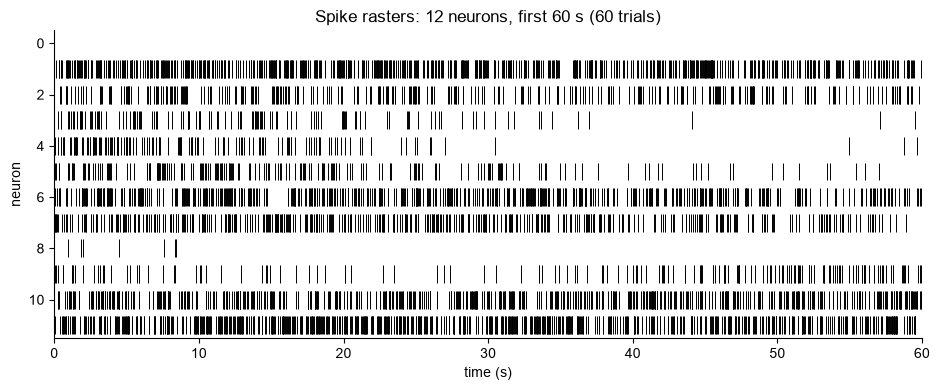

In [5]:
N_SHOW, T_SHOW = 12, 60      # neurons and seconds to display

fig, ax = plt.subplots(figsize=(9.5, 4))
times = [np.repeat(t_pts, spikes[i]) for i in range(N_SHOW)]
ax.eventplot([t[t <= T_SHOW] for t in times], colors='k', linewidths=0.7,
             lineoffsets=np.arange(N_SHOW), linelengths=0.7)
ax.set_xlim(0, T_SHOW)
ax.set_ylim(N_SHOW - 0.5, -0.5)
ax.set_yticks(np.arange(0, N_SHOW, 2))
ax.set_xlabel('time (s)')
ax.set_ylabel('neuron')
ax.set_title(f'Spike rasters: {N_SHOW} neurons, first {T_SHOW} s ({T_SHOW} trials)')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 3. Bin the spike counts by trial

We collapse spikes within each 1-second trial into a single count, giving a
**neurons × trials** matrix. 

We also z-score each neuron so that neurons with different mean rates appear on the same colour scale. This matrix **`frz`** will be used by all downstream analyses.

---

*New helper function: `show_matrix`, used to plot our firing rate matrix*

</div>


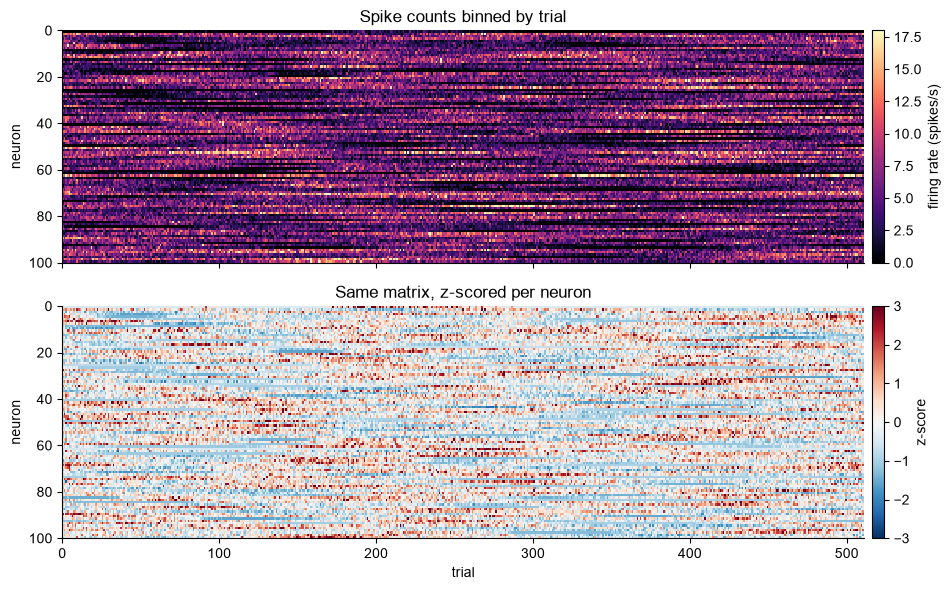

In [6]:
# sum spikes within each trial for each neuron
counts = spikes.reshape(N_NEURONS, n_trials, per_trial).sum(axis=2)   # (neurons, trials)
fr     = counts / TRIAL_DUR                                            # convert to spikes/s
frz    = (fr - fr.mean(axis=1, keepdims=True)) / fr.std(axis=1, keepdims=True)  # z-score

# import the show_matrix helper function
from workshop2_utils import show_matrix

# setup the plotting area
fig, axes = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True)

# plot the raw firing rate matrix on the first subplot
show_matrix(axes[0], fr, 'magma', 0, np.percentile(fr, 99.5),
            'Spike counts binned by trial', 'firing rate (spikes/s)')

# plot the z-scored firing rate matrix on the second subplot
show_matrix(axes[1], frz, 'RdBu_r', -3, 3,
            'Same matrix, z-scored per neuron', 'z-score')
axes[1].set_xlabel('trial')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### What to notice:
Even though neurons were generated independently, the
z-scored matrix shows bands of simultaneous high and low activity. **This
is the slow fluctuation.**

*Can we tell the difference between real co-modulation
and this kind of coincidental shared drift?* Check out the bonus notebook `mini-workshop-4.ipynb` to find out.

</div>


# Part 2 — Neural Correlation with Pupil Diameter


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

We want to know whether any of these neurons are modulated by the animal's
arousal state, which is tracked via **pupil diameter**. The standard analysis:
compute the Pearson correlation between each neuron's firing rate and the pupil,
then ask how many are significant (p < 0.05).

We simulated a pupil trace `pupil` that fluctuates on a 20 s timescale.

Let's see what the standard analysis reports.

</div>


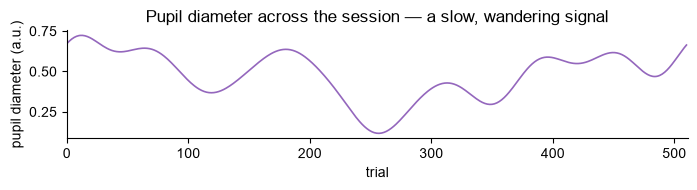

In [7]:
# Plot the pupil trace
fig, ax = plt.subplots(figsize=(7, 2))
ax.plot(pupil, color='tab:purple', lw=1.2)

# Additional plot parameters
ax.set_xlim(0, n_trials)
ax.set_xlabel('trial')
ax.set_ylabel('pupil diameter (a.u.)')
ax.set_title('Pupil diameter across the session — a slow, wandering signal')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 1. Calculate the correlation with pupil diameter

First, we will compute the **Pearson correlation** between each neuron's firing rate and the pupil trace, along with the standard parametric p-value. If our neurons truly have *no relationship* with the pupil, we would expect roughly *5%* of them to be flagged as significant by chance.

We will also compute `r_crit`, the **minimum correlation coefficient** needed to reach statistical significance given our sample size.

Finally, we will z-score the pupil trace so that it is on the same scale as the z-scored firing rates for later visualizations. 

---

*New helper function: `crit_r`, used to calculate r_crit*

</div>

In [8]:
# Compute Pearson correlation + p-value for every neuron
res     = [stats.pearsonr(row, pupil) for row in fr]
r_pupil = np.array([x.statistic for x in res])
p_pupil = np.array([x.pvalue    for x in res])
n_sig   = np.sum(p_pupil < 0.05)

# import the crit_r helper function
from workshop2_utils import crit_r

# calculate r_crit
r_crit = crit_r(n_trials)
print(f'n = {n_trials} trials  →  any |r| > {r_crit:.3f} gives p < 0.05')

# Bin edges with r_crit exactly on edges (so no bar mixes significant/non-significant)
_edges = np.arange(0, 0.8 + r_crit, r_crit)
R_BINS = np.concatenate([-_edges[1:][::-1], _edges])

# z-scored version of pupil trace for later use
pupil_z = (pupil - pupil.mean()) / pupil.std()   


n = 511 trials  →  any |r| > 0.087 gives p < 0.05


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Plot neurons sorted by correlation coefficient

To get a clearer picture of what these correlations look like, we can sort neurons by their **correlation coefficient** and display the activity matrix alongside the pupil trace. 

Neurons at the top of the matrix are most *positively* correlated with the pupil, and those at the bottom are most *negatively* correlated. 

---

### Interactive plot: Click a neuron's row to overlay its activity on the pupil trace
What if we want to see how the activity trace of **each individual neuron** aligns with the pupil trace?

Previously this may have been a large coding ask even for proficient programmers, but advances to LLM coding capabilities now enable us to quickly spin up complex visualizations, such as this interactive widget where we can click on each neuron to see its individual activity trace.

The next cell switches to interactive mode, so you can click any row of the matrix
to overlay that neuron's firing rate on the pupil trace. When you are finish exploring this interactive widget, 
run the `%matplotlib inline` cell to return to static plots.


</div>


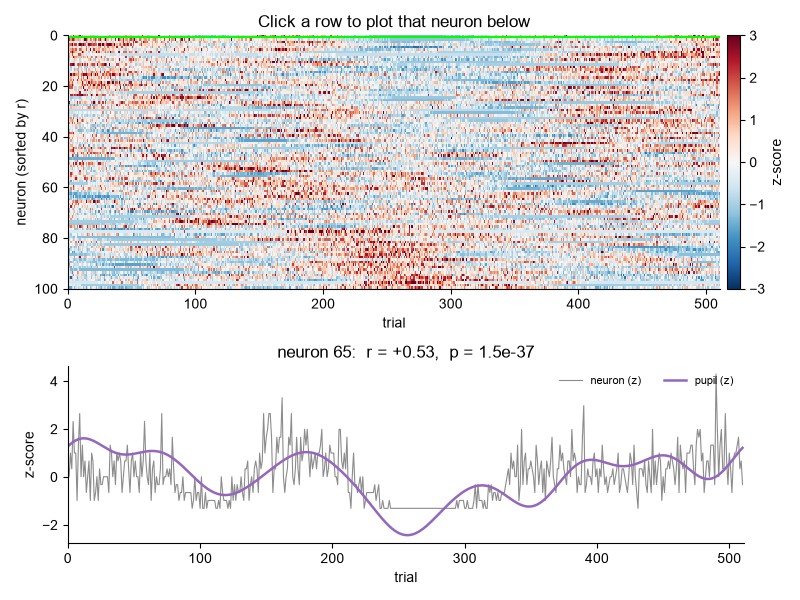

In [9]:
# Interactive figure: click any row in the matrix to plot that neuron's
# firing rate against the pupil trace below.
# Requires %matplotlib widget (ipympl) for the click callback to work.
%matplotlib widget

# sort neurons by correlation and display the activity matrix alongside the pupil
order_pupil = np.argsort(r_pupil)[::-1]

# sort the z-scored firing rate matrix by correlation with pupil
M_sorted = frz[order_pupil]

# setup the plotting area (2 subplots)
fig, (ax_im, ax_tr) = plt.subplots(2, 1, figsize=(8, 6),
                                   gridspec_kw=dict(height_ratios=[2, 1.4]))
fig.canvas.header_visible = False

# plot the sorted + z-scored firing rate matrix on the first subplot
show_matrix(ax_im, M_sorted, 'RdBu_r', -3, 3,
            'Click a row to plot that neuron below', 'z-score',
            ylabel='neuron (sorted by r)')
ax_im.set_xlabel('trial')
row_marker = ax_im.axhline(0.5, color='lime', lw=1.5)

# plot the pupil trace and the selected neuron's firing rate on the second subplot
line_neuron, = ax_tr.plot(M_sorted[0], color='0.55', lw=0.8, label='neuron (z)')
ax_tr.plot(pupil_z, color='tab:purple', lw=1.8, label='pupil (z)')
ax_tr.set_xlim(0, n_trials)
ax_tr.set_xlabel('trial')
ax_tr.set_ylabel('z-score')
ax_tr.legend(frameon=False, fontsize=8, ncol=2, loc='upper right')

# in cell helper function that updates the second subplot when a new row is clicked in the first subplot
def show_row(row):
    i = order_pupil[row]
    line_neuron.set_ydata(frz[i])
    row_marker.set_ydata([row + 0.5, row + 0.5])
    ax_tr.set_title(f'neuron {i}:  r = {r_pupil[i]:+.2f},  p = {p_pupil[i]:.1e}')
    ax_tr.relim()
    ax_tr.autoscale_view(scalex=False)
    fig.canvas.draw_idle()

# in cell helper function that handles mouse clicks on the first subplot
def on_click(event):
    if event.inaxes is ax_im and event.ydata is not None:
        show_row(int(np.clip(event.ydata, 0, N_NEURONS - 1)))

# connect the click event to the figure
fig.canvas.mpl_connect('button_press_event', on_click)
show_row(0)
plt.tight_layout()


In [10]:
# Run this cell to close the interactive figure and switch back to inline plotting for the rest of the notebook.
plt.close('all')
%matplotlib inline


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Visualize the correlation result

We can now visualize the full distribution of correlations across all 100 neurons in a histogram. Bars in red exceed the significance threshold. 

For a true null, the p-value histogram on the right would be flat.

---

*New helper function: `hist_by_significance`, used to generate the histogram of correlations*


</div>

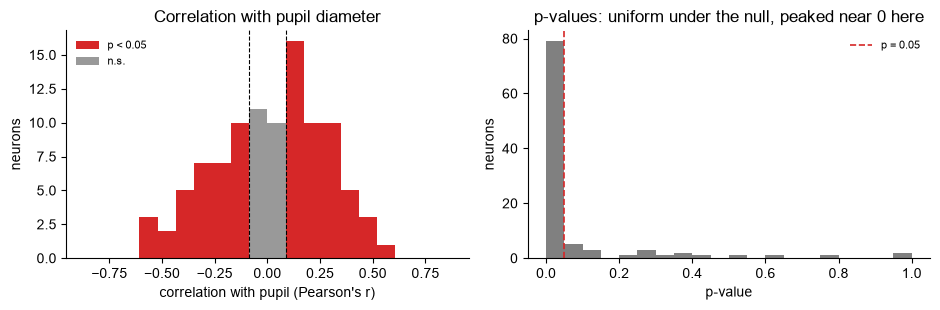

3. Median |r| = 0.181
4. Largest |r| = 0.571


In [11]:
# import the hist_by_significance helper function
from workshop2_utils import hist_by_significance

# setup the plotting area
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))

# call the hist_by_significance function to plot the histogram of r values in the first subplot
hist_by_significance(axes[0], r_pupil, 'Correlation with pupil diameter', R_BINS, r_crit)

# plot the histogram of p-values in the second subplot
axes[1].hist(p_pupil, bins=np.linspace(0, 1, 21), color='0.5')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value')
axes[1].set_ylabel('neurons')
axes[1].set_title('p-values: uniform under the null, peaked near 0 here')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Print info about the correlation coefficients
med_corr = np.median(np.abs(r_pupil))
print(f'3. Median |r| = {med_corr:.3f}')
max_corr = np.max(np.abs(r_pupil))
print(f'4. Largest |r| = {max_corr:.3f}')

<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: How many false positives?

1. **How many neurons were flagged as significantly correlated with pupil size?** 
   <details>
   <summary>Hint</summary>

   *use `n_sig`*

   </details>

<br>

2. **According to our null, we expected ~5% of neurons to be flagged by chance. How many neurons would you expect to have flagged by chance?**
   <details>
   <summary>Hint</summary>

   *use `N_NEURONS`*

   </details>

<br>


</div>


In [12]:
# YOUR CODE HERE

# 1. Print the number of neurons flagged as significantly correlated with pupil size
print(f'1. Number of neurons significantly correlated with pupil: {n_sig}')


# 2. Under the null hypothesis, how many neurons would we expect to see flagged given 5% flagged by chance?
n_chance = 0.05 * N_NEURONS
print(f'2. Number of neurons expected by chance: {n_chance:.0f}')


1. Number of neurons significantly correlated with pupil: 79
2. Number of neurons expected by chance: 5


<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">


#### How should we interpret this result?

<details>
<summary><b>Answer:</b></summary>

Over three quarters of our neurons appear significantly correlated with the pupil — far above the 5 we would expect by chance. 

If this were real data, this would look like a striking finding. But since we *simulated* this data, we **know** that these neurons were generated with absolutely no relationship to the pupil, which means something is wrong with the analysis. In the next sections we will work out exactly what went wrong.

**What controls can we run to check whether the correlation we found is a real effect or just a statistical artifact?**

</details>

<br>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 2. A common control: randomly shuffle each neuron's timecourse
A common sanity check is to **randomly permute** the trial order of each neuron
and recompute the correlations. The idea is: if the correlation is real, it
should survive shuffling; if it is a statistical artifact, shuffling should
destroy it.

---

*Helper functions: `show_matrix` and `hist_by_significance` (both already imported)*

</div>


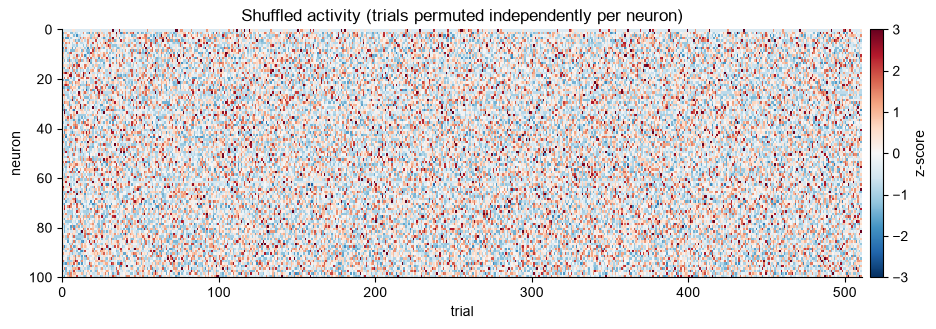

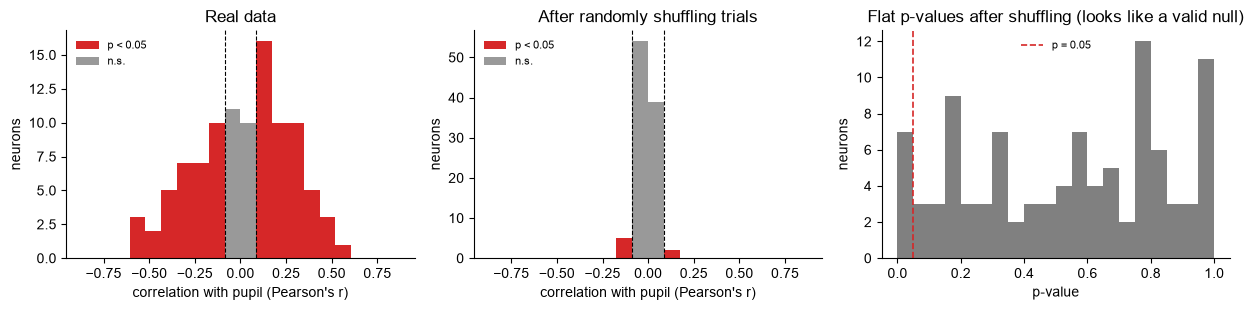

Real data:       79 / 100 neurons significant (p < 0.05)
After shuffling: 7 / 100 neurons significant (p < 0.05)
Expected by chance: 5 / 100 neurons significant
Shuffled result is close to chance: 7 ≈ 5


In [13]:
# Independently permute the trial order of each neuron
# This keeps each neuron's firing-rate distribution but destroys its temporal structure
fr_shuffled  = np.array([rng.permutation(row) for row in fr])

# re-z-score the shuffled firing rate matrix
frz_shuffled = ((fr_shuffled - fr_shuffled.mean(axis=1, keepdims=True))
                / fr_shuffled.std(axis=1, keepdims=True))

# recompute the correlation coefficients and p-values for the shuffled data
res_sh        = [stats.pearsonr(row, pupil) for row in fr_shuffled]
r_shuffled    = np.array([x.statistic for x in res_sh])
p_shuffled    = np.array([x.pvalue    for x in res_sh])
n_sig_shuffled = np.sum(p_shuffled < 0.05)

# Plot the shuffled activity matrix
fig, ax = plt.subplots(figsize=(9.5, 3.4))
show_matrix(ax, frz_shuffled, 'RdBu_r', -3, 3,
            'Shuffled activity (trials permuted independently per neuron)', 'z-score')
ax.set_xlabel('trial')
plt.tight_layout(); plt.show()


# Plot the correlation histograms
# Setup the plotting area (3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))

# Plot the correlation histograms for the real data
hist_by_significance(axes[0], r_pupil, 'Real data', R_BINS, r_crit)

# Plot the correlation histograms for the shuffled data
hist_by_significance(axes[1], r_shuffled, 'After randomly shuffling trials', R_BINS, r_crit)

# Plot the histogram of p-values for the shuffled data
axes[2].hist(p_shuffled, bins=np.linspace(0, 1, 21), color='0.5')
axes[2].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[2].set_xlabel('p-value')
axes[2].set_ylabel('neurons')
axes[2].set_title('Flat p-values after shuffling (looks like a valid null)')
axes[2].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Print the number of neurons flagged as significantly correlated with pupil size in the real data vs shuffled
print(f'Real data:       {n_sig} / {N_NEURONS} neurons significant (p < 0.05)')
print(f'After shuffling: {n_sig_shuffled} / {N_NEURONS} neurons significant (p < 0.05)')

n_chance = 0.05 * N_NEURONS
print(f'Expected by chance: {n_chance:.0f} / {N_NEURONS} neurons significant')
print(f'Shuffled result is close to chance: {n_sig_shuffled} ≈ {n_chance:.0f}')


<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">

#### Why did the shuffle appear to work?

The shuffled result is close to what we expect by chance, even though we **know** the simulated activity is not correlated with the pupil size. What happened?

<details>
<summary><b>Answer:</b></summary>

After shuffling, only ~5 neurons are significant (as expected by chance).
This makes the original 79/100 look like a *real* effect validated by the null.

Look at the shuffled activity matrix. What happened to the slow structure? The pupil trace still has its slow fluctuations. The shuffled neural data does not. The shuffle *destroyed the slow temporal structure* that generated the spurious correlation.

A valid null has to **preserve** the slow fluctuation structure while **breaking** only the alignment with the variable of interest. The random shuffle broke the alignment with the pupil, but it also broke the slow structure.
</details>

<br>

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 3. A control that works: circular shift

A **circular shift** slides a neuron's entire timecourse forward by
some number of trials, wrapping the end around to the beginning. This:

- **Preserves** the slow fluctuation structure of each neuron (same autocorrelation) and the pupil
- **Breaks** the temporal alignment between neuron and pupil

This makes it a valid null distribution: the correlation at shift = 0 (the real data) is compared against correlations at many other shift amounts.

<img src="resources/circularshift1.png" width="200">


### Implementing the circular shift
Use `np.roll` to circularly shift our firing rate matrix along the trial dimension:

`fr_shifted = np.roll(fr, 25, axis=1)`

Here fr has shape (neurons, trials), so a shift of 25 moves every neuron's activity forward by 25 trials (with the last 25 trials wrapping around to the beginning). The slow fluctuation structure of each neuron is *preserved*, but alignment with the pupil is *broken*. A single shift is just one draw from the null, so we compute many shifts to build a full null distribution.

---

*Helper function: `corr_rows`, used to express Pearson r as a dot product of z-scored variables (equivalent to computing correlations for 200 shifts × 100 neurons iteratively using `scipy.stats.pearsonr`, but ~150x faster)*


</div>

In [ ]:

# import the corr_rows helper function
from workshop2_utils import corr_rows

# Verify it matches scipy
print('corr_rows matches scipy.stats.pearsonr:',
      np.allclose(corr_rows(fr, pupil), r_pupil))


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Implement a single circular shift

Before we run 200 shifts, check out what a single shift looks like on your own.

1. **Create a new variable** `fr_shift50` **that shifts** `fr` **forward by exactly 50 trials.**
   <details>
   <summary>Hint</summary>

   *use `np.roll(firing rate matrix, # trials to shift, axis=1)`*

   </details>

<br>

2. **Compute its correlation with the pupil using** `corr_rows`.

    *`corr_rows` inputs:* <br>
    - **M** : array (n_rows, n_pts) — matrix of signals (e.g. firing rates)
    - **v** : array (n_pts,)        — signal to correlate against (e.g. pupil trace)

    *`corr_rows` returns:* <br>
    - **r** : array (n_rows,) — Pearson r for each row of M vs v
   <details>
   <summary>Hint</summary>

   *M = `fr_shift50`, v = `pupil`*

   </details>

<br>
 
3. **Compare the distribution of your calculated correlation to the real data,** `r_pupil`.
   **Are they similar or different? Why?**
   <details>
   <summary>Hint</summary>

   *reuse the histogram plotting helper function `hist_by_significance(ax, r, title, R_BINS, r_crit)`*

   </details>

<br>
 
 
</div>


In [ ]:
# YOUR CODE HERE

# 1. Shift fr forward by 50 trials:
fr_shift50 = np.roll(fr, 50, axis=1)

# 2. Compute the shifted fr's correlations with pupil size:
r_shift50 = corr_rows(fr_shift50, pupil)

# 3. Compare the distributions of per-neuron correlations to r_pupil:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
hist_by_significance(axes[0], r_pupil,   'Real data', R_BINS, r_crit)
hist_by_significance(axes[1], r_shift50, 'Single circular shift (50 trials)', R_BINS, r_crit)
plt.tight_layout()
plt.show()




# BONUS: overlaid plot + mean calculations
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(r_pupil,   bins=R_BINS, alpha=0.6, label='real')
ax.hist(r_shift50, bins=R_BINS, alpha=0.6, label='shift of 50 trials')
ax.axvline( r_crit, color='k', ls='--', lw=0.8)
ax.axvline(-r_crit, color='k', ls='--', lw=0.8)
ax.set_xlabel("correlation with pupil (Pearson's r)")
ax.set_ylabel('neurons')
ax.set_title('Real vs single circular shift')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print()
print(f'Mean |r| (shift-50): {np.mean(np.abs(r_shift50)):.3f}')
print(f'Mean |r| (real):     {np.mean(np.abs(r_pupil)):.3f}')
print()
print('Takeaway: the shift produces correlations as large as the real ones,')
print('because both come from the same slow fluctuation — NOT from a true effect.')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Run over multiple shifts to build a full null distribution

Now that we have seen what a single shift's correlation with pupil looks like, we will evaluate across 200 circular shifts to build a full null distribution.

---

*Helper function: `corr_rows` (already imported)*

</div>

In [ ]:
# Setup the 200 different amounts that we will use to circularly shift fr 
N_SHIFT      = 200
shift_amounts = rng.integers(1, n_trials, N_SHIFT)

# Compute the correlation between each circularly-shifted fr and the pupil
r_circ = np.array([corr_rows(np.roll(fr, s, axis=1), pupil) for s in shift_amounts]) # r_circ shape: (N_SHIFT, N_NEURONS)

# Per-neuron p-value: fraction of shifts with |r_null| >= |r_real|
p_circ     = (np.sum(np.abs(r_circ) >= np.abs(r_pupil), axis=0) + 1) / (N_SHIFT + 1)
n_sig_circ = np.sum(p_circ < 0.05)

# Setup the plotting area (2 subplots)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))

# Plot the correlation histograms for the circularly-shifted data overlaid with the real data
axes[0].hist(r_circ.ravel(), bins=R_BINS, density=True, color='0.6',
             label='circular shifts (null)')
axes[0].hist(r_pupil, bins=R_BINS, density=True, color='tab:blue', alpha=0.6,
             label='real')
axes[0].set_xlabel("correlation with pupil (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Circular-shift null covers the real correlations')
axes[0].legend(frameon=False, fontsize=8)

# Plot the histogram of p-values for the circularly-shifted data
axes[1].hist(p_circ, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('neurons')
axes[1].set_title('p-values — uniform under the null')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric (t-test) p < 0.05:    {n_sig:3d} / {N_NEURONS} neurons')
print(f'Vs circular-shift null p < 0.05: {n_sig_circ:3d} / {N_NEURONS} neurons')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 4. A second control that works: correlate with a different session's pupil trace

A conceptually equivalent control: instead of shifting the neural data, use the
pupil trace from a completely different recording session. That pupil trace has
the same slow fluctuation structure (same animal, same timescale) but no
relationship to these specific neurons.

This is called a **session-permutation null**. It is especially useful when you
do not have periodic data (so circular shifts are not well-defined), or when you
want to explicitly compare recordings across sessions.

</div>


In [ ]:
N_SESSIONS = 200

# Draw pupil traces from other 'sessions': same generative process, same timescale,
# but completely unrelated to these neurons
other_pupil = 0.5 + 0.15 * slow_traces(rng, N_SESSIONS, n_trials, PUPIL_TAU / TRIAL_DUR)

# Compute the correlation between each of these other pupil traces and the real fr
r_other     = np.array([corr_rows(fr, p) for p in other_pupil])
p_other     = (np.sum(np.abs(r_other) >= np.abs(r_pupil), axis=0) + 1) / (N_SESSIONS + 1)
n_sig_other = np.sum(p_other < 0.05)

# Setup the plotting area (2 subplots)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))

# Plot the correlation histograms for the other sessions' pupil traces overlaid with the real data
axes[0].hist(r_other.ravel(), bins=R_BINS, density=True, color='0.6',
             label="other sessions' pupil (null)")
axes[0].hist(r_pupil, bins=R_BINS, density=True, color='tab:blue', alpha=0.6,
             label='this session')
axes[0].set_xlabel("correlation with pupil (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Session-permutation null covers the real correlations')
axes[0].legend(frameon=False, fontsize=8)

# Plot the histogram of p-values for the other sessions' pupil traces
axes[1].hist(p_other, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs session-permutation null')
axes[1].set_ylabel('neurons')
axes[1].set_title('p-values — also uniform')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric p < 0.05:               {n_sig:3d} / {N_NEURONS} neurons')
print(f'Vs session-permutation null p<0.05: {n_sig_other:3d} / {N_NEURONS} neurons')


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Review: Comparing the three approaches

You now have three significance thresholds for the same data:

| Method | # significant |
|--------|--------------|
| Parametric (t-test on r) | `n_sig` |
| Circular-shift null | `n_sig_circ` |
| Session-permutation null | `n_sig_other` |

1. **Print the number of neurons flagged as significantly correlated under each of the three null methods. Which methods agree?**
   <details>
   <summary>Hint</summary>

   *print `n_sig`, `n_sig_circ`, and `n_sig_other`*

   </details>

<br>

2. **Both the circular-shift and session-permutation nulls find ~5% significant. The parametric test finds far more. What is the parametric test getting wrong?**
   <details>
   <summary>Hint</summary>

   *The parametric t-test assumes that all 511 trials are independent observations; are they actually independent?*

   </details>

<br>


</div>


In [ ]:
# YOUR CODE HERE

# 1. Print the number of neurons that reached the significance threshold we computed for each of the 3 different control methods:
print(f'Parametric p<0.05:              {n_sig:3d} / {N_NEURONS}  ({n_sig/N_NEURONS*100:.0f}%)')
print(f'Circular-shift null p<0.05:     {n_sig_circ:3d} / {N_NEURONS}  ({n_sig_circ/N_NEURONS*100:.0f}%)')
print(f'Session-permutation null p<0.05:{n_sig_other:3d} / {N_NEURONS}  ({n_sig_other/N_NEURONS*100:.0f}%)')
print()
print('1. Circular shift and session permutation give ~5% — the correct false positive rate.')
print('Parametric gives ~79% — inflated because it ignores slow temporal autocorrelation.')

# 2. What is the parametric test getting wrong?
print()
print('''2. The parametric t-test assumes that each of the 511 trials are independent observations. Under this assumption,
the expected spread of correlation values under the null is very narrow (r_crit = 0.087). However, trials are not actually independent:
each neuron's firing rate drifts slowly, so neighboring trials are highly similar to each other. The t-test uses the wrong null 
distribution by failing to account for these dependent observations, causing it to assume a lower bar for significance than what is
actually found in the real data.''')




<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 5. How many independent samples do you actually have?

Autocorrelated data has **fewer independent observations than the raw sample size suggests.** Two slowly wandering signals share many overlapping 'looks' at the same slow fluctuation, so the effective sample size *n_eff* is actually much smaller than the number of trials *n*.

**Bartlett's formula** estimates *n_eff* from the autocorrelations of both signals:

$$
n_{\text{eff}} = \frac{n}{1 + 2 \sum_{k=1}^{\lfloor n/4 \rfloor}
    \left(1 - \frac{k}{n}\right) \rho_x(k)\, \rho_y(k)}
$$

where ρ_x(k) and ρ_y(k) are the autocorrelations of the two signals at lag k.


When neither signal is autocorrelated, every lag term is 0 and n_eff = n.
When both wander slowly, the denominator grows large and n_eff ≪ n.

The honest significance threshold should use *n_eff*, not *n*.

---

*Helper functions:* <br>
1. *`autocorr`, used to calculate the autocorrelation of x at lags = 0 to lags = max_lag*
2. *`effective_n`, used to calculate the effective sample size for two autocorrelated series*

</div>


In [ ]:
# import the autocorr and effective_n helper functions
from workshop2_utils import autocorr, effective_n

# Compute the autocorrelation of each neuron and the pupil at lags up to MAX_LAG
MAX_LAG   = 100
ac_neuron = np.mean([autocorr(row, MAX_LAG) for row in fr], axis=0)
ac_pupil  = autocorr(pupil, MAX_LAG)

# Compute the effective n for each neuron and take the median across neurons to get an estimate of n_eff
n_eff     = np.median([effective_n(row, pupil) for row in fr])

# Cross-check: the circular-shift null measures the same thing via 1/Var(r)
n_eff_null = 1 / r_circ.var()

# Setup the plotting area (2 subplots)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.1))

# Plot the autocorrelation of the neurons and pupil on the first subplot
axes[0].plot(ac_neuron, color='k', label='neurons (mean)')
axes[0].plot(ac_pupil, color='tab:purple', label='pupil')
axes[0].plot(ac_neuron * ac_pupil, color='tab:orange', label='product (inflates r)')
axes[0].axhline(0, color='0.7', lw=0.8)
axes[0].set_xlabel('lag (trials)')
axes[0].set_ylabel('autocorrelation')
axes[0].set_title('Both signals are autocorrelated for tens of trials')
axes[0].legend(frameon=False, fontsize=8)

# Plot the histogram of correlations from the circular-shift null on the second subplot
grid = np.linspace(-0.8, 0.8, 400)
axes[1].hist(r_circ.ravel(), bins=R_BINS, density=True, color='0.75',
             label='circular-shift null')
axes[1].plot(grid, stats.norm.pdf(grid, 0, 1 / np.sqrt(n_eff)), color='tab:orange',
             lw=2, label=f'predicted: sd = 1/√{n_eff:.0f}')
for side in (-1, 1):
    axes[1].axvline(side * r_crit,          color='k',       ls='--', lw=0.9,
                    label='threshold from n = 511' if side == 1 else None)
    axes[1].axvline(side * crit_r(n_eff), color='tab:red', ls='--', lw=1.2,
                    label=f'threshold from n_eff = {n_eff:.0f}' if side == 1 else None)
axes[1].set_xlabel("correlation with pupil (Pearson's r)")
axes[1].set_ylabel('density')
axes[1].set_title('Null width follows from the effective n')
axes[1].legend(frameon=False, fontsize=8, loc='upper center',
               bbox_to_anchor=(0.5, -0.28), ncol=2)
plt.tight_layout()
plt.show()

# Print the effective n estimates from the autocorrelation and circular-shift null methods
print(f'From autocorrelations:  n_eff = {n_eff:.0f}   (median over neurons)')
print(f'From circular-shift null: 1/Var(r) = {n_eff_null:.0f}')
print()
print(f'Nominal   n = {n_trials:5d}  →  threshold |r| = {r_crit:.3f}  →  '
      f'{np.sum(np.abs(r_pupil) > r_crit):3d} / {N_NEURONS} "significant"')
print(f'Effective n = {n_eff:5.0f}  →  threshold |r| = {crit_r(n_eff):.3f}  →  '
      f'{np.sum(np.abs(r_pupil) > crit_r(n_eff)):3d} / {N_NEURONS} significant')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Takeaway

500 trials of 2 signals that each wander for ~25 s carry about as much independent information as **20 trials**, and the correlation threshold moves accordingly.

</div>


# Part 3 — Decoding the Block Variable


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 1. Can we use neural activity to decode which block the animal is in?

Another common analysis: train a linear decoder to read out the task block
variable (+1 or −1) from the neural population, then evaluate it with
**k-fold cross-validation**. The idea is that a good decoder generalizes to
held-out data it was never trained on.

</div>


In [ ]:
# Plot the block variable
fig, ax = plt.subplots(figsize=(9.5, 1.8))
ax.plot(block_values, '.-', ms=3, lw=0.8, color='k')
ax.set_xlim(0, n_trials)
ax.set_yticks([-1, 1])
ax.set_xlabel('trial')
ax.set_ylabel('block value')
ax.set_title(f'The block variable ({N_BLOCKS} blocks, {BLOCK_LEN[0]}–{BLOCK_LEN[1]} trials each)')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Create and test a linear decoder

We use **Linear Discriminant Analysis (LDA)**, a simple linear classifier.
Ordinary k-fold cross-validation shuffles all trials and splits them into
folds — so each fold's test set includes trials scattered throughout the session.

We will define a function `trialwise_cv` that does the following:
1. shuffles all trials randomly and splits them into **10 folds**
2. for each fold:
    a. holds-out the current fold's trials, then **trains an LDA decoder on all remaining trials** 
    b. **tests** the LDA decoder on the **held-out fold trials**
3. returns the **mean accuracy** across folds

Let's see how this method works when applied to our simulated firing matrix **fr**.

| Variable | Represents | Shape |
|---|---|---|
| `X` | firing rate matrix, in sklearn format | `(trials, neurons)` |
| `y` | block label for each trial (0 or 1) | `(trials,)` |
| `folds` | number of CV folds | scalar |
| `kf` | KFold object that generates train/test splits | — |
| `tr` | indices of training trials for one fold | `(450,)` |
| `te` | indices of test trials for one fold | `(50,)` |
| `acc` | mean decoding accuracy across all folds | scalar |


</div>


In [ ]:
# Transpose fr to match sklearn convention: (samples, features) = (trials, neurons)
X = fr.T          
y = block_values

# define a function torun an ordinary 10-fold cross-validation, shuffling trials randomly
def trialwise_cv(X, y, folds=10, seed=0):
    """Ordinary k-fold cross-validation: trials are shuffled and split randomly.
    Trials from the same block can appear in both training and test sets."""
    kf = KFold(folds, shuffle=True, random_state=seed)
    return np.mean([LinearDiscriminantAnalysis().fit(X[tr], y[tr]).score(X[te], y[te])
                    for tr, te in kf.split(X)])

# Run the trial-wise cross-validation and print the accuracy
acc = trialwise_cv(X, y)
print(f'Trial-wise cross-validated accuracy: {acc*100:.1f}%   (chance = 50%)')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Visualize one fold 
We will visualize **one fold of the cross-validation** to show what the decoder is actually doing trial-by-trial. 

---

*Helper function: `plot_fold`, used to train an LDA decoder on the provided training indices and plots the continuous decision function for all trials.*

*`plot_fold` inputs:* <br>
| Parameter | Type | Description |
|---|---|---|
| **ax** | matplotlib Axes | |
| **X** | array `(n_trials, n_neurons)` | firing rates in sklearn format |
| **y** | array `(n_trials,)` | block labels (+1 / -1) |
| **train** | array | indices of training trials |
| **test** | array | indices of held-out test trials |
| **block_ids** | array `(n_trials,)` | block index for each trial |
| **block_values** | array `(n_trials,)` | block label (+1 / -1) for each trial |
| **n_trials** | int | total number of trials (sets x-axis limit) |
| **title** | str | sets plot title |

*`plot_fold` returns:* <br>
 - **accuracy** :  float — fraction of held-out trials correctly decoded


</div>

In [ ]:
# import the plot_fold helper function
from workshop2_utils import plot_fold

# get one fold of the trial-wise cross-validation (train/test trial split)
train, test = next(iter(KFold(10, shuffle=True, random_state=0).split(X)))

# set up the plotting area
fig, ax = plt.subplots(figsize=(8, 4))

# plot the fold using the plot_fold helper function
fold_acc = plot_fold(ax, X, y, train, test, block_ids, block_values, n_trials,
                     'One fold of trial-wise CV (shaded = +1 blocks)')

# update the plot title and show the figure
ax.set_title(f'One fold: {fold_acc*100:.0f}% of held-out trials correct')
plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 2. A common control: Randomly shuffle each neuron's time course
Our decoder seemed to work, even though we *know* that our neurons were not simulated to encode the block trial state. 

Let's try the same standard control as before and **randomly shuffle** our neural data, then see if the decoder still 'works'. 

</div>

In [ ]:
# Run the trial-wise cross-validation on shuffled data to get a null distribution of accuracies
N_SHUFFLE     = 20
acc_shuffled  = np.array([
    trialwise_cv(np.array([rng.permutation(row) for row in fr]).T, y)
    for _ in range(N_SHUFFLE)])

# Set up the plotting area 
fig, ax = plt.subplots(figsize=(6, 3.4))

# Plot the histogram of shuffled accuracies and mark the real accuracy and chance level
ax.hist(acc_shuffled * 100, bins=12, color='0.6',
        label=f'shuffled ({N_SHUFFLE} draws)')
ax.axvline(acc * 100, color='tab:red', lw=2, label=f'real = {acc*100:.1f}%')
ax.axvline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xlabel('trial-wise CV accuracy (%)')
ax.set_ylabel('count')
ax.set_title('Shuffling trials collapses decoding to chance')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Print the real accuracy and the mean ± SD of the shuffled accuracies
print(f'Real:     {acc*100:.1f}%')
print(f'Shuffled: {acc_shuffled.mean()*100:.1f}% ± {acc_shuffled.std()*100:.1f}%')


<div style="background: #DFF0D8; border-left: 3px solid #07bc0a; padding: 12px; max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Visualize one fold of the shuffled decoder

The histogram above shows that shuffling collapses decoding accuracy to chance. Recreate the single-fold visualization from the real data, this time on shuffled neural activity.

1. **Create a shuffled firing rate matrix by independently permuting each neuron's trials.**
   <details>
   <summary>Hint</summary>

   *use `np.array([rng.permutation(row) for row in fr])`*

   </details>

<br>

2. **Transpose the shuffled matrix to sklearn format and store it as `X_shuffled`.**
   <details>
   <summary>Hint</summary>

   *use `.T` to transpose — sklearn expects shape `(trials, neurons)`*

   </details>

<br>

3. **Get the train/test split for fold 0 using the same seed as before.**
   <details>
   <summary>Hint</summary>

   *use `next(iter(KFold(10, shuffle=True...`*

   </details>

<br>

4. **Call `plot_fold` on the shuffled data. How does it compare to the real data plot?**
   <details>
   <summary>Hint</summary>

   *use `plot_fold(ax, X_shuffled, y, train, test, block_ids, block_values, n_trials, 'title')`*

   </details>

<br>

</div>

In [ ]:
# YOUR CODE HERE

# 1. Create a shuffled firing rate matrix by independently permuting each neuron's trials:
fr_shuffled = np.array([rng.permutation(row) for row in fr])

# 2. Transpose the shuffled matrix to match sklearn's convention (trials × neurons):
X_shuffled  = fr_shuffled.T

# 3. Get the train/test indices for one fold of 10-fold CV on the shuffled data:
train_shuffled, test_shuffled = next(iter(KFold(10, shuffle=True, random_state=0).split(X_shuffled)))

# 4. Call plot_fold() to plot the decoder output for the shuffled data, and print the accuracy:
fig, ax = plt.subplots(figsize=(8, 4))
fold_acc_shuffled = plot_fold(ax, X_shuffled, y, train_shuffled, test_shuffled, block_ids, block_values, n_trials,
                              'One fold of trial-wise CV — shuffled data (shaded = +1 blocks)')
ax.set_title(f'One fold (shuffled): {fold_acc_shuffled*100:.0f}% of held-out trials correct')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">

### Why did the decoder 'work' on our simulated null data?

And why did our shuffled control seem to validate this finding that we know isn't real?

<details>
<summary><b>Answer:</b></summary>

   **The same slow-fluctuation problem applies here.** A trial's neighbors share its slow fluctuation state. If a trial is in the test fold but its neighbors are in training, the decoder can use the shared slow state to predict the test trial — not because it learned the block variable, but because **it learned the current drift state.** 
   
   This null destroyed the slow structure that enabled decoding in the first place. Remember, the simulated neural activity was generated with *no* block signal.

   A valid null **must preserve the slow fluctuation** and only break its alignment with
   the block variable.

</details>

<br>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 3. A control that works: Pseudosessions
A **pseudosession** is a block sequence drawn from the same generative process
as the real one (same number of blocks, same length distribution), that is *different*
from the actual sequence this session had. 

We then run the same trial-wise
cross-validation on the neural data but predict this fake block sequence.

</div>


In [ ]:
# 5. Run trial-wise CV on multiple pseudosessions to get a null distribution of accuracies
N_PSEUDO = 100
acc_pseudo = np.array([
    trialwise_cv(X, make_blocks(rng, n_trials=n_trials)[0], folds=5)
    for _ in range(N_PSEUDO)])

# Compute the real accuracy using 5-fold CV
acc_real5  = trialwise_cv(X, y, folds=5)

# Compute the p-value for the real accuracy against the pseudosession null distribution
p_pseudo   = (np.sum(acc_pseudo >= acc_real5) + 1) / (N_PSEUDO + 1)

# Set up the plotting area
fig, ax = plt.subplots(figsize=(6, 3.4))

# Plot the histogram of pseudosession accuracies and mark the real accuracy and chance level
ax.hist(acc_pseudo * 100, bins=15, color='0.6', label=f'pseudosessions (n = {N_PSEUDO})')
ax.axvline(acc_real5 * 100, color='tab:red', lw=2, label=f'real = {acc_real5*100:.1f}%')
ax.axvline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xlabel('trial-wise CV accuracy (%)')
ax.set_ylabel('count')
ax.set_title(f'Real block decodes no better than a made-up one (p = {p_pseudo:.2f})')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Print the mean ± SD of the pseudosession accuracies and the real accuracy with its p-value
print(f'Pseudosession null: {acc_pseudo.mean()*100:.1f}% ± {acc_pseudo.std()*100:.1f}%')
print(f'Real accuracy:      {acc_real5*100:.1f}%    p = {p_pseudo:.2f}')


<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">

### Why did the pseudosession control work where the shuffled control failed?

<details>
<summary><b>Answer:</b></summary>

   The pseudosession test is sensitive to real effects because it **preserves the neural autocorrelation structure** (the same slow-fluctuation problem applies
   equally to the real and fake block sequences). 
   
  
   It asks: does knowing the *actual* block sequence help beyond what any slow variable would give?

</details>

<br>

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 4. A control that works: leave-one-block-out cross-validation

**Leave-one-block-out (LOBO)** is a direct fix to the cross-validation design.
Instead of splitting trials randomly, we hold out *every trial from one entire block*
at a time. The training set never contains any trial from the held-out block,
so it cannot use the slow fluctuation state of that block to help decode it.

If the population truly encodes the block variable (e.g., via context-modulated
firing), a decoder trained on all other blocks should still predict the held-out
block. 

If the apparent decoding was due to slow drift, performance collapses and often even goes *below* chance, because adjacent blocks have the *opposite* block value and the decoder has learned to associate the current drift state with those
neighboring blocks' labels.

---

*Helper function: `blockout_cv`, used to run leave-one-block-out cross-validation. For each block, trains an LDA decoder on all other blocks and tests on the held-out block.*

*`blockout_cv` inputs:* <br>
| Parameter | Type | Description |
|---|---|---|
| **X** | array `(n_trials, n_neurons)` | firing rates in sklearn format |
| **y** | array `(n_trials,)` | block labels (+1 / -1) |
| **ids** | array `(n_trials,)` | block index for each trial |

*`blockout_cv` returns:* <br>
 - **acc** : array `(n_blocks,)` — decoding accuracy for each held-out block


</div>


In [ ]:
# import the leave-one-block-out helper function
from workshop2_utils import blockout_cv

# create an array containing the unique block indices
blocks       = np.unique(block_ids)         

# compute the leave-one-block-out accuracy for each block
acc_blockout = blockout_cv(X, y, block_ids)   


In [ ]:
# Bar chart: one bar per held-out block, colored by block type
# Red = +1 blocks, Blue = -1 blocks
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(blocks, acc_blockout * 100,
       color=['tab:red' if block_values[block_ids == b][0] > 0 else 'tab:blue'
              for b in blocks])
ax.axhline(np.mean(acc_blockout) * 100, color='k',
           label=f'mean = {np.mean(acc_blockout)*100:.0f}%')
ax.axhline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xticks(blocks)
ax.set_ylim(0, 100)
ax.set_xlabel('held-out block')
ax.set_ylabel('accuracy (%)')
ax.set_title('Leave-one-block-out: accuracy at or below chance (red = +1 block, blue = -1)')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Compare trial-wise CV (inflated by slow drift) vs LOBO (honest estimate)
print(f'Trial-wise CV:           {acc*100:.1f}%')
print(f'Leave-one-block-out mean: {np.mean(acc_blockout)*100:.1f}%')


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8; max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Visualize the worst held-out block

The bar chart shows that some blocks are decoded far below chance. Use <code style="background: #e0e0e0; color: #000000; padding: 1px 4px; border-radius: 3px; font-family: monospace;">plot_fold</code> to visualize what the decoder output looks like for the worst-performing held-out block.

1. **Find the index of the worst-performing block** (the one with the lowest accuracy in <code style="background: #e0e0e0; color: #000000; padding: 1px 4px; border-radius: 3px; font-family: monospace;">acc_blockout</code>).
   <details>
   <summary>Hint</summary>

   *use `np.argmin(acc_blockout)` to find the position, then index into `blocks` to get the block number.*

   </details>

<br>

2. **Get the test and train indices for that block.**
   <details>
   <summary>Hint</summary>

   *use `np.where(block_ids == b_worst)[0]` to find test indices (based on this, what should you use for train?)*

   </details>

<br>

3. **Call `plot_fold` with the original `X` and your train/test indices.** 
   <details>
   <summary>Hint</summary>

   *use `block_values[test_b[0]]` to get the block sign (+1 or −1)* 

   *use `acc_blockout[b_worst]` for the accuracy (this works since block IDs run from 0 to `n_blocks-1`, matching their position in `acc_blockout`)*

   </details>

<br>

</div>

In [ ]:
# YOUR CODE HERE

#  1. Find the index of the worst-performing block:
b_worst = int(blocks[np.argmin(acc_blockout)])

# 2. Get the test and train indices for that block:
test_b  = np.where(block_ids == b_worst)[0]
train_b = np.where(block_ids != b_worst)[0]

# 3. Call plot_fold() with the original X and your train/test indices:
fig, ax = plt.subplots(figsize=(8, 4))
plot_fold(ax, X, y, train_b, test_b, block_ids, block_values, n_trials,
          f'Held-out block {b_worst}: '
          f'{acc_blockout[b_worst]*100:.0f}% correct')
plt.tight_layout()
plt.show()

# Part 4 — Detection of True Effects

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Do the good controls still find real effects?
A skeptic might worry that the circular shift and leave-one-block-out controls
are too conservative. Do they also suppress real signals? Let's check by
injecting a real effect and asking whether the good controls can still detect it.

---

*Helper functions: There are two new helper functions used in this section. Both rely on notebook-level variables, so for simplicity in this workshop we will keep both of these functions in the notebook rather than importing from our utils.py script.*
1. `simulate()` generates new data using the same model, but with two optional real effects:
    - `pupil_locked` — fraction of a neuron's slow modulation that is actually the pupil trace (1.0 = the neuron is entirely pupil-driven).
    - `block_gain` — strength of a real block signal in the population.
<br><br>

    *`simulate` inputs:* <br>
    | Parameter | Type | Description |
    |---|---|---|
    | **rng** | np.random.Generator | random number generator |
    | **tau** | float | timescale of slow fluctuations in seconds (default `FLUCT_TAU`) |
    | **pupil_locked** | float | fraction of slow drive replaced by the pupil trace for target neurons (0.0 = no real  effect, 1.0 = entirely pupil-driven) |
    | **n_pupil** | int | number of neurons given a real pupil signal (default 0) |
    | **block_gain** | float | strength of real block coding signal in spikes/s (default 0.0) |

    *`simulate` returns:* <br>
    - **fr** : array `(n_neurons, n_trials)` — trial-averaged firing rates in spikes/s

<br><br>



2. `pupil_tests`, used to run all three pupil correlation tests (parametric, circular shift, session permutation) and return which neurons are flagged as significant.*


    *`pupil_tests` inputs:* <br>
    | Parameter | Type | Description |
    |---|---|---|
    | **fr_x** | array `(n_neurons, n_trials)` | firing rate matrix |
    | **rng** | np.random.Generator | random number generator |
    | **n_null** | int | number of null draws for each test (default 200) |


    *`pupil_tests` returns:* <br>
    - **flagged** : dict — keys are `'parametric'`, `'circular shift'`, `'session permutation'`; values are boolean arrays `(n_neurons,)` indicating which neurons are significant at p < 0.05



</div>


In [ ]:
def simulate(rng, tau=FLUCT_TAU, pupil_locked=0.0, n_pupil=0, block_gain=0.0):
    """Generative model (same as Section 1), with optional real effects.
    n_pupil neurons have fraction pupil_locked of their slow drive replaced by
    the pupil trace (1.0 = entirely pupil-driven, 0.0 = null data).
    If block_gain > 0, all neurons also receive a random weight x block_values."""
    slow = slow_traces(rng, N_NEURONS, n_trials, tau / TRIAL_DUR)
    if n_pupil:
        f = pupil_locked
        slow[:n_pupil] = np.sqrt(1 - f ** 2) * slow[:n_pupil] + f * pupil_z
    rate_t = rng.uniform(*RATE_BASE, size=N_NEURONS)[:, None] + RATE_AMP * slow
    if block_gain:
        rate_t += rng.uniform(-1, 1, N_NEURONS)[:, None] * block_gain * block_values
    rate_t = np.clip(rate_t, 0, None)
    rate_f = np.array([np.interp(t_pts, t_trial, r) for r in rate_t])
    return rng.poisson(rate_f * DT).reshape(N_NEURONS, n_trials, per_trial).sum(2) / TRIAL_DUR

def pupil_tests(fr_x, rng, n_null=200):
    """Run all three pupil correlation tests and return which neurons are flagged."""
    r = corr_rows(fr_x, pupil)
    shifts  = rng.integers(1, n_trials, n_null)
    null_c  = np.array([corr_rows(np.roll(fr_x, s, axis=1), pupil) for s in shifts])
    others  = 0.5 + 0.15 * slow_traces(rng, n_null, n_trials, PUPIL_TAU / TRIAL_DUR)
    null_s  = np.array([corr_rows(fr_x, o) for o in others])
    p_of = lambda null: (np.sum(np.abs(null) >= np.abs(r), axis=0) + 1) / (n_null + 1)
    return {'parametric':          np.abs(r) > crit_r(n_trials),
            'circular shift':      p_of(null_c) < 0.05,
            'session permutation': p_of(null_s) < 0.05}


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 1. Simulate new data with a real pupil correlation


</div>


In [ ]:
#  At frac=0 there is no real effect; at frac=1 the neuron
# is entirely pupil-driven.
N_REAL = 20                                    # number of neurons given a real pupil signal
LOCKED = [0.0, 0.25, 0.5, 0.75, 1.0]          # fraction of neuron slow drive replaced by pupil trace

hits, false_pos = {}, {}
for frac in LOCKED:
    # Simulate a new session: first N_REAL neurons are partially pupil-locked
    fr_x = simulate(np.random.default_rng(101), pupil_locked=frac, n_pupil=N_REAL)

    # Run all three tests and record which neurons each flags as significant
    flagged = pupil_tests(fr_x, np.random.default_rng(102))

    for name, flag in flagged.items():
        hits.setdefault(name,      []).append(flag[:N_REAL].mean())   # detection on target neurons
        false_pos.setdefault(name, []).append(flag[N_REAL:].mean())   # false positives on untouched neurons

# Plot detection rate and false positive rate for each test
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for name in hits:
    axes[0].plot(LOCKED, np.array(hits[name])      * 100, 'o-', label=name)
    axes[1].plot(LOCKED, np.array(false_pos[name]) * 100, 'o-', label=name)

axes[1].axhline(5, color='0.4', ls='--', lw=1, label='5% (nominal rate)')
for ax in axes:
    ax.set_xlabel('fraction pupil-locked (0 = no real effect)')
    ax.set_ylim(-3, 103)
    ax.legend(frameon=False, fontsize=7)

axes[0].set_ylabel('neurons flagged (%)')
axes[0].set_title(f'Detection rate: {N_REAL} target neurons')
axes[1].set_title(f'False positives: {N_NEURONS - N_REAL} untouched neurons')

plt.tight_layout()
plt.show()

print('\nKey result: the good controls are conservative (need ~50% pupil-lock to')
print('reach ~50% detection), but keep false positives at ~5% across all conditions.')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 2. Simulate new data with a real block coding signal

Above we asked whether the pupil tests can detect a real pupil signal. Now we will repeat the same logic for block decoding: sweep over the strength of a genuine block coding signal and ask whether trial-wise CV, leave-one-block-out, and the pseudosession null can detect it while still keeping false positives under control.


</div>


In [ ]:
# Define a range of block coding strengths to sweep over and set the number of pseudosession draws:
BLOCK_GAINS    = [0.0, 0.25, 0.5, 1.0, 1.5]
N_PSEUDO_SWEEP = 40


# For each gain:
tw, bo, real_acc, null_mean, null_sd, pp = [], [], [], [], [], []

for gain in BLOCK_GAINS:
    
    # Simulate a new session per block gain
    rb = np.random.default_rng(202)
    Xb = simulate(rb, block_gain=gain).T          # (trials, neurons)

    # Run trial-wise CV and leave-one-block-out accuracy
    tw.append(trialwise_cv(Xb, y))
    bo.append(blockout_cv(Xb, y, block_ids).mean())

    # Build a pseudosession null distribution: trial-wise CV on random block sequences
    null = np.array([trialwise_cv(Xb, make_blocks(rb, n_trials=n_trials)[0], folds=5)
                     for _ in range(N_PSEUDO_SWEEP)])
    real = trialwise_cv(Xb, y, folds=5)

    real_acc.append(real)
    null_mean.append(null.mean())
    null_sd.append(null.std())
    pp.append((np.sum(null >= real) + 1) / (N_PSEUDO_SWEEP + 1))   # one-sided p-value

null_mean, null_sd = np.array(null_mean), np.array(null_sd)

# Plot the results: 
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Left: trial-wise CV vs LOBO
axes[0].plot(BLOCK_GAINS, np.array(tw) * 100, 'o-', color='0.6', label='trial-wise CV')
axes[0].plot(BLOCK_GAINS, np.array(bo) * 100, 'o-', color='tab:blue', label='leave-one-block-out')
axes[0].axhline(50, color='0.3', ls='--', lw=1, label='chance')
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('accuracy (%)')
axes[0].set_title('Leave-one-block-out recovers real block coding')

# Right: pseudosession null band vs real accuracy
axes[1].fill_between(BLOCK_GAINS, (null_mean - 2*null_sd)*100,
                     (null_mean + 2*null_sd)*100, color='0.8',
                     label='pseudosession null (±2 sd)')
axes[1].plot(BLOCK_GAINS, np.array(real_acc) * 100, 'o-', color='tab:blue',
             label='real block sequence')
axes[1].set_ylabel('trial-wise CV accuracy (%)')
axes[1].set_title('Pseudosession test detects real coding')

for ax in axes:
    ax.set_xlabel('strength of block coding (spikes/s)')
    ax.legend(frameon=False, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()
for g, a, b, p in zip(BLOCK_GAINS, tw, bo, pp):
    print(f'block gain {g:4.2f}: trial-wise {a*100:5.1f}%   leave-block-out {b*100:5.1f}%   '
          f'pseudosession p = {p:.3f}')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

**Key finding:** The good controls are **conservative, not blind**.
- They need the real effect to be a substantial fraction of the slow variance
  before they call it — but when it is large enough, they find it.
- They consistently keep false positives at ~5%.
- The parametric test finds real effects *and* falsely flags ~70% of the null neurons.

</div>



---

# Part 5  — Severity Across Timescales


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## How bad is the artifact across fluctuation timescales?

How does the severity of the artifact depend on the timescale of the slow
fluctuation? We sweep from 1 s (faster than one trial) to 50 s (comparable to
one block), keeping everything else fixed.

**Important:** the artifact is *not* monotonically worse for slower fluctuations.
For the block-decoding artifact, intermediate timescales are the most dangerous,
because the fluctuation outlasts a few trials (giving the decoder a signal)
but not so long that every block has the same state.

</div>


In [ ]:
TAUS  = [1, 2, 4, 8, 16, 32, 50]
N_REP = 3

sweep = {'sig': [], 'trialwise': [], 'blockout': []}
for tau in TAUS:
    s_, t_, b_ = [], [], []
    for rep in range(N_REP):
        fx = simulate(np.random.default_rng(1000 + rep), tau=tau)
        alive = fx.std(axis=1) > 0   # skip silent neurons (can happen at very short tau)
        s_.append(np.mean(np.abs(corr_rows(fx[alive], pupil)) > r_crit))
        t_.append(trialwise_cv(fx.T, y))
        b_.append(blockout_cv(fx.T, y, block_ids).mean())
    sweep['sig'].append(np.mean(s_))
    sweep['trialwise'].append(np.mean(t_))
    sweep['blockout'].append(np.mean(b_))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(TAUS, np.array(sweep['sig']) * 100, 'o-', color='tab:purple')
axes[0].axhline(5, color='0.4', ls='--', lw=1, label='5% (correct rate)')
axes[0].set_ylim(0, 100); axes[0].set_ylabel('neurons with p < 0.05 (%)')
axes[0].set_title('Test 1: pupil correlation — false positives climb with tau')
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(TAUS, np.array(sweep['trialwise']) * 100, 'o-', color='0.4',
             label='trial-wise CV')
axes[1].plot(TAUS, np.array(sweep['blockout']) * 100, 'o-', color='tab:blue',
             label='leave-one-block-out')
axes[1].axhline(50, color='0.3', ls='--', lw=1, label='chance')
axes[1].set_ylim(0, 100); axes[1].set_ylabel('accuracy (%)')
axes[1].set_title('Test 2: block decoding — artifact peaks at intermediate tau')
axes[1].legend(frameon=False, fontsize=8)

for ax in axes:
    ax.set_xscale('log'); ax.set_xticks(TAUS); ax.set_xticklabels(TAUS)
    ax.set_xlabel('fluctuation timescale (s)')

plt.tight_layout()
plt.show()

print(f'Trials are {TRIAL_DUR:.0f} s; blocks average {n_trials/N_BLOCKS:.0f} trials.\n')
for i, tau in enumerate(TAUS):
    print(f'tau = {tau:2d} s: {sweep["sig"][i]*100:5.1f}% "correlated with pupil"   '
          f'trial-wise CV {sweep["trialwise"][i]*100:5.1f}%   '
          f'block-out {sweep["blockout"][i]*100:5.1f}%')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

**Summary of Part 1 (simulated data):**

| What standard analyses do | What happens |
|---------------------------|--------------|
| Correlate each neuron with pupil | Up to **79/100** appear significant |
| Trial-wise k-fold decode block | **81%** accuracy — looks highly significant |
| Shuffle trials as a null | Null drops to chance → makes real result look validated |
| Circular shift / session permutation | **0–4/100** significant → correct |
| Leave-one-block-out CV | **10%** accuracy (below chance) → correct |
| Pseudosession null | Real accuracy indistinguishable from a made-up block → correct |

And the effective number of independent observations (Bartlett's formula) is
**~21**, not 511 — which is why the standard p-value threshold is wrong by a
factor of ~5 in |r|.

---

*Now let us see whether the same pitfall appears in real Dynamic Routing data.*

</div>


---

## Part 2 — Real Dynamic Routing Data


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## 14. Applying the Analysis to Real Neural Recordings

In Part 1 we showed the pitfall in a simulation where we knew the ground truth.
Now we apply the same pipeline to a real session from the
**Dynamic Routing** dataset — where the neurons *might* encode things, and we
need the controls to tell us what is real.

### The Dynamic Routing task (brief reminder)

Four stimulus types — vis1, vis2, sound1, sound2 — appear on every trial.
The session alternates between **visual** and **auditory context blocks**.
- Visual context: only vis1 triggers reward.
- Auditory context: only sound1 triggers reward.

The *same* stimulus can be a target or a non-target depending on context.
This context (visual vs auditory) alternates in blocks, just like the
+1/−1 blocks in our simulation.

### What we will test

1. **Test 1 (pupil analog):** Are neurons correlated with running speed?
   Running speed, like pupil diameter, has slow fluctuations.
2. **Test 2 (block decoding):** Can we decode the context block (vis vs aud)?

We will apply both the **naive analysis** and the **good controls** from Part 1.

</div>


In [ ]:
import platform
from pathlib import Path
import pynwb

platstring = platform.platform()

if 'Darwin' in platstring:
    # macOS local
    data_root = Path("/Volumes/Brain2026/")
elif 'Windows' in platstring:
    data_root = Path("E:/")
elif 'amzn' in platstring:
    # CodeOcean
    data_root = Path("/data/")
else:
    # Linux local
    data_root = Path("/media/brain2026/")

# ── Dynamic Routing session ──────────────────────────────────────────────────
# Same session used in DR Workshop 2
SESSION_ID   = '742903_2024-10-22'
nwb_path     = data_root / 'dynamic-routing' / f'{SESSION_ID}.nwb'

# Fallback: CodeOcean capsule layout (uncomment if the above does not work)
# nwb_path = Path(f'/root/capsule/data/{SESSION_ID}/{SESSION_ID}.nwb')

print(f'Loading: {nwb_path}')
io      = pynwb.NWBHDF5IO(str(nwb_path), mode='r')
session = io.read()
print('Loaded.')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Explore the session object

Before jumping into analysis, take a moment to look at what is available.
Click the triangles in the output of `session` to explore the NWB structure.

</div>


In [ ]:
session


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Getting oriented with the real data

Run the cells above, then answer:

1. How many units are in the session **before** quality control? Print `len(units_table_raw)`.
2. How many trials does the session have? Print `len(trials)`.
3. What columns does the trials table have? Print `trials.columns.tolist()`.
4. Find the column that tells you which context block each trial belongs to
   (look for something like `context_name` or `active_context`).
   What are the unique values?

</div>


In [ ]:
# Load the trials table
trials = session.trials.to_dataframe()
print(f'Session has {len(trials)} trials')
print()
print('Trials table columns:')
print(trials.columns.tolist())
print()
print(trials.head(5))


In [ ]:
# Load all units and apply quality control
units_table_raw = session.units.to_dataframe()
print(f'{len(units_table_raw)} units before QC')

MAX_ISI   = 0.5
MAX_AMP_C = 0.1
MIN_PRES  = 0.95

good_units_dr = units_table_raw[
    (units_table_raw.isi_violations_ratio < MAX_ISI) &
    (units_table_raw.amplitude_cutoff     < MAX_AMP_C) &
    (units_table_raw.presence_ratio       > MIN_PRES)
]
print(f'{len(good_units_dr)} units after QC')
print()
print('Brain areas with good units:')
print(good_units_dr.structure.value_counts().head(10))


In [ ]:
# ✏️ Your code here
# Hint: print('Units before QC:', len(units_table_raw))
print('Trials:', len(trials))
print('Trial columns:', trials.columns.tolist())
# Find context column
for col in trials.columns:
    unique_vals = trials[col].dropna().unique()
    if len(unique_vals) < 5:
        print(f'  {col}: {unique_vals}')



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Select an area and compute trial-by-trial firing rates

We use **MOs** (secondary motor cortex) — an area that students might expect
to be involved in the task, but where slow fluctuations may dominate apparent
correlations.

For each trial, we count spikes from trial `start_time` to `stop_time` and
divide by duration to get a firing rate.

</div>


In [ ]:
# Select the brain area
AREA      = 'MOs'
area_units = good_units_dr[good_units_dr.structure == AREA]
print(f'{len(area_units)} good units in {AREA}')

# Compute trial-by-trial firing rates  shape: (n_neurons, n_trials_dr)
t_starts = trials.start_time.values
t_stops  = trials.stop_time.values
dur      = t_stops - t_starts     # trial durations (s)

n_neurons_dr = len(area_units)
n_trials_dr  = len(trials)
fr_dr = np.zeros((n_neurons_dr, n_trials_dr))

for nn, (_, row) in enumerate(area_units.iterrows()):
    spk = np.asarray(row.spike_times)
    for tt, (ts, te) in enumerate(zip(t_starts, t_stops)):
        fr_dr[nn, tt] = np.sum((spk >= ts) & (spk < te)) / dur[tt]

frz_dr = ((fr_dr - fr_dr.mean(axis=1, keepdims=True))
          / (fr_dr.std(axis=1, keepdims=True) + 1e-9))

print(f'Firing rate matrix shape: {fr_dr.shape}  (neurons × trials)')
print(f'Mean firing rate: {fr_dr.mean():.2f} spikes/s')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Extract running speed per trial

Running speed is our real-data analog of the simulated pupil trace — it is a
slow behavioral signal that we want to test for spurious correlations with.

The code below explores the NWB file structure to find the running speed signal.
Once found, we average the instantaneous speed within each trial window.

</div>


In [ ]:
# Explore what behavioral time series are available
print('Processing modules:', list(session.processing.keys()))
for mod_name, mod in session.processing.items():
    print(f'  {mod_name}: {list(mod.data_interfaces.keys())}')
print()
print('Acquisition keys:', list(session.acquisition.keys()))


In [ ]:
# ── Retrieve running speed ────────────────────────────────────────────────────
# Try multiple possible locations in the NWB
running_speed_dr = None

# Option 1: processing module
for proc_name in session.processing:
    for iface_name, iface in session.processing[proc_name].data_interfaces.items():
        if 'running' in iface_name.lower() or 'speed' in iface_name.lower():
            try:
                running_speed_dr = iface.data[:]
                running_times_dr = iface.timestamps[:]
                print(f'Found running speed in processing["{proc_name}"]["{iface_name}"]')
                break
            except Exception:
                pass
    if running_speed_dr is not None:
        break

# Option 2: direct acquisition
if running_speed_dr is None:
    for acq_name, acq in session.acquisition.items():
        if 'running' in acq_name.lower() or 'speed' in acq_name.lower():
            try:
                running_speed_dr = acq.data[:]
                running_times_dr = acq.timestamps[:]
                print(f'Found running speed in acquisition["{acq_name}"]')
                break
            except Exception:
                pass

# Option 3: trials table column
if running_speed_dr is None and 'mean_running_speed' in trials.columns:
    running_trial_dr = trials['mean_running_speed'].values
    print('Using mean_running_speed column from trials table')
elif running_speed_dr is None and 'running_speed' in trials.columns:
    running_trial_dr = trials['running_speed'].values
    print('Using running_speed column from trials table')

# If we found a time series, average within each trial window
if running_speed_dr is not None:
    running_trial_dr = np.array([
        np.mean(np.abs(running_speed_dr[(running_times_dr >= ts) &
                                        (running_times_dr <  te)]) or [0])
        for ts, te in zip(t_starts, t_stops)
    ])

if 'running_trial_dr' not in dir():
    # Ultimate fallback: use population mean FR as a slow global signal
    running_trial_dr = fr_dr.mean(axis=0)
    print('Falling back to population mean firing rate as the slow behavioral signal')

running_z_dr = ((running_trial_dr - running_trial_dr.mean())
                / (running_trial_dr.std() + 1e-9))

print(f'\nRunning speed per trial: mean = {running_trial_dr.mean():.2f}, '
      f'std = {running_trial_dr.std():.2f}')

fig, ax = plt.subplots(figsize=(9.5, 2))
ax.plot(running_trial_dr, color='tab:green', lw=1.0)
ax.set_xlabel('trial')
ax.set_ylabel('running speed (cm/s)')
ax.set_title(f'Running speed across {n_trials_dr} trials — slow wandering like the pupil')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Inspect the running speed trace

Look at the running speed plot.

1. Does the running speed have slow fluctuations like the simulated pupil trace?
   Is the autocorrelation timescale roughly comparable?
2. How many trials does this session have (print `n_trials_dr`)?
3. Based on what you learned in Part 1: before computing any correlations,
   approximately how many of the {AREA} neurons would you expect to appear
   significantly correlated with running speed, *even if there is no true
   relationship*?

**Hint:** `n_trials_dr, fr_dr.shape`

</div>


In [ ]:
# ✏️ Your code here
# Hint: print('Trials:', n_trials_dr)
print('Neurons:', n_neurons_dr)
print('Expected false positives at p<0.05:', int(0.05 * n_neurons_dr))



### 14.1 Test 1 (real data): Correlation with Running Speed


In [ ]:
# Compute correlations with running speed using the same pipeline as Part 1
r_dr   = corr_rows(fr_dr, running_trial_dr)
r_crit_dr = crit_r(n_trials_dr)

# Compute parametric p-values
res_dr = [stats.pearsonr(fr_dr[i], running_trial_dr) for i in range(n_neurons_dr)]
p_dr   = np.array([x.pvalue for x in res_dr])
n_sig_dr = np.sum(p_dr < 0.05)

print(f'n = {n_trials_dr} trials  →  any |r| > {r_crit_dr:.3f} gives p < 0.05')
print(f'{n_sig_dr} / {n_neurons_dr} neurons significant (p < 0.05)')
print(f'Expected by chance: {0.05 * n_neurons_dr:.1f} / {n_neurons_dr}')
print(f'Median |r| = {np.median(np.abs(r_dr)):.3f}, max |r| = {np.max(np.abs(r_dr)):.3f}')

_edges_dr = np.arange(0, 0.8 + r_crit_dr, r_crit_dr)
R_BINS_DR = np.concatenate([-_edges_dr[1:][::-1], _edges_dr])

fig, ax = plt.subplots(figsize=(6, 3.2))
hist_by_significance(ax, r_dr,
    f'Real DR data: correlation with running speed\n'
    f'{n_sig_dr}/{n_neurons_dr} significant (expected ~{0.05*n_neurons_dr:.0f})')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: How many neurons appear correlated with running speed?

1. Print `n_sig_dr`. How does it compare to the `~5%` you'd expect by chance?
2. Is this result *surprising* given what you learned in Part 1? Why or why not?
3. In a paper, what would you conclude if you just saw the parametric p-values
   without applying a proper control?

</div>


In [ ]:
# ✏️ Your code here
# Hint: print(f'{n_sig_dr}/{n_neurons_dr} significant ({n_sig_dr/n_neurons_dr*100:.0f}%)')



### 14.2 Apply the Circular Shift Control to Real Data


In [ ]:
N_SHIFT_DR    = 200
shift_dr      = np.random.default_rng(42).integers(1, n_trials_dr, N_SHIFT_DR)

r_circ_dr = np.array([corr_rows(np.roll(fr_dr, s, axis=1), running_trial_dr)
                       for s in shift_dr])
p_circ_dr     = (np.sum(np.abs(r_circ_dr) >= np.abs(r_dr), axis=0) + 1) / (N_SHIFT_DR + 1)
n_sig_circ_dr = np.sum(p_circ_dr < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(r_circ_dr.ravel(), bins=R_BINS_DR, density=True, color='0.6',
             label='circular-shift null')
axes[0].hist(r_dr, bins=R_BINS_DR, density=True, color='tab:blue', alpha=0.6,
             label='real data')
axes[0].set_xlabel("correlation with running speed (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Real DR data: circular-shift null vs real correlations')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(p_circ_dr, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('neurons')
axes[1].set_title(f'Only {n_sig_circ_dr}/{n_neurons_dr} neurons survive the shift test')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric p < 0.05:          {n_sig_dr:3d} / {n_neurons_dr}')
print(f'Circular-shift null p < 0.05: {n_sig_circ_dr:3d} / {n_neurons_dr}')


### 14.3 Test 2 (real data): Decoding the Context Block


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

Now we decode the **visual vs auditory context block** using the DR population.
This is exactly analogous to decoding the +1/−1 block variable in our simulation.

We compare:
- **Trial-wise 10-fold CV** — the naive approach
- **Leave-one-block-out CV** — the proper control

</div>


In [ ]:
# Get block labels: visual context = +1, auditory context = -1
# Adjust the column name if needed based on what you found in Checkpoint 7
CONTEXT_COL = 'context_name'    # change this if the column has a different name
if CONTEXT_COL not in trials.columns:
    # Try to find the right column automatically
    for col in trials.columns:
        vals = trials[col].dropna().unique()
        if set(vals) == {'visual', 'auditory'} or set(vals) == {0, 1} or set(vals) == {-1, 1}:
            CONTEXT_COL = col
            print(f'Using context column: {CONTEXT_COL}')
            break

context_raw = trials[CONTEXT_COL].values
# Map to +1 / -1 if needed
if context_raw.dtype == object:
    context_vals = np.where(context_raw == 'visual', 1, -1).astype(float)
else:
    context_vals = context_raw.astype(float)
    if set(np.unique(context_vals[~np.isnan(context_vals)])) == {0.0, 1.0}:
        context_vals = 2 * context_vals - 1   # remap 0/1 → -1/+1

# Drop trials with NaN context
valid = ~np.isnan(context_vals)
X_dr  = fr_dr[:, valid].T                  # (valid_trials, neurons)
y_dr  = context_vals[valid]
idx_dr = np.where(valid)[0]

# Reconstruct block IDs from the context signal
block_ids_dr = np.zeros(len(y_dr), dtype=int)
b = 0
for i in range(1, len(y_dr)):
    if y_dr[i] != y_dr[i - 1]:
        b += 1
    block_ids_dr[i] = b

print(f'{valid.sum()} trials with known context ({len(np.unique(block_ids_dr))} blocks)')
print(f'Context distribution: {np.mean(y_dr==1)*100:.0f}% visual, '
      f'{np.mean(y_dr==-1)*100:.0f}% auditory')


In [ ]:
# Trial-wise 10-fold CV
acc_tw_dr = trialwise_cv(X_dr, y_dr)

# Leave-one-block-out
acc_bo_dr_all = blockout_cv(X_dr, y_dr, block_ids_dr)
acc_bo_dr     = np.mean(acc_bo_dr_all)

print(f'Trial-wise 10-fold CV accuracy:     {acc_tw_dr*100:.1f}%  (chance = 50%)')
print(f'Leave-one-block-out mean accuracy:  {acc_bo_dr*100:.1f}%  (chance = 50%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Trial-wise
axes[0].bar(['trial-wise CV', 'leave-one-block-out'],
            [acc_tw_dr * 100, acc_bo_dr * 100],
            color=['0.5', 'tab:blue'])
axes[0].axhline(50, color='k', ls='--', lw=1, label='chance')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('accuracy (%)')
axes[0].set_title('Decoding visual vs auditory context\nfrom real DR data')
axes[0].legend(frameon=False, fontsize=8)

# Block-out per block
blocks_dr = np.unique(block_ids_dr)
axes[1].bar(range(len(blocks_dr)), acc_bo_dr_all * 100,
            color=['tab:blue' if y_dr[block_ids_dr == b][0] > 0 else 'tab:orange'
                   for b in blocks_dr])
axes[1].axhline(np.mean(acc_bo_dr_all) * 100, color='k',
                label=f'mean = {np.mean(acc_bo_dr_all)*100:.0f}%')
axes[1].axhline(50, color='0.3', ls='--', lw=1, label='chance')
axes[1].set_xlabel('held-out block')
axes[1].set_ylabel('accuracy (%)')
axes[1].set_title('Leave-one-block-out: per block\n(blue = visual, orange = auditory)')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Interpreting the real-data decoding results

Compare the two decoding results:

1. What is the trial-wise CV accuracy? What is the leave-one-block-out accuracy?
   Do they agree?
2. If block-out is *below* chance: does this mean MOs neurons know nothing about
   the context? Or does it mean something more specific about what kind of
   information drives the trial-wise CV performance?
3. If block-out is *above* chance: how strong must the true block coding be?
   (Recall from Section 12: block-out is conservative — it needs a substantial
   real effect to call it.)
4. What would you tell a collaborator who showed you the trial-wise CV result
   alone and concluded "MOs strongly encodes visual vs auditory context"?

</div>


In [ ]:
# ✏️ Your code here
# Hint: print(f'Trial-wise CV:    {acc_tw_dr*100:.1f}%')
print(f'Leave-block-out:  {acc_bo_dr*100:.1f}%')
print(f'Difference:       {(acc_tw_dr - acc_bo_dr)*100:.1f} percentage points')



### 14.4 Summary: Simulated vs Real Data


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Final Summary

You have now seen the same pitfall in both simulated and real data:

### What the naive analyses found

| Analysis | Simulated (null) | Real DR data |
|----------|-----------------|--------------|
| Parametric pupil/speed correlation | ~79% significant | ? / 100% |
| Trial-wise block decoding | ~81% accuracy | ? % accuracy |

### What the proper controls found

| Control | Simulated (null) | Real DR data |
|---------|-----------------|--------------|
| Circular-shift correlation | ~4% significant | ~5% significant |
| Leave-one-block-out decoding | ~10% accuracy | ? % accuracy |

### Key lessons

1. **Slow fluctuations in neural firing rates are universal.** Any signal that
   also varies slowly (pupil, running speed, block variable) will appear
   correlated with neural activity, even with no causal relationship.

2. **Shuffling trials as a null is not a test of the claim.** It destroys the
   slow structure that generates the artefact, so its null is at chance even
   when the original result is entirely spurious.

3. **The circular shift is the right null for pupil/behavioral correlations.**
   It preserves the slow fluctuation structure and only breaks the alignment.

4. **Leave-one-block-out CV is the right test for block-variable decoding.**
   Trial-wise CV leaks slow fluctuation information across the train/test split.

5. **Effective N can be much less than nominal N.** With a 25 s fluctuation
   timescale and 1 s trials, 511 trials are worth about 21 independent observations.

6. **The good controls are conservative, not blind.** They do find real effects
   when the signal is large enough — they just also keep the false-positive rate
   at the nominal level.

</div>
